# Feature Engineering

This notebook covers the feature engineering pipeline for the 525 Bird Species dataset.
This includes augmentation (train only) and normalization, transforming raw PIL images into tensors ready for model training.

## 1. Load Dataset

In [1]:
from datasets import load_dataset
from pathlib import Path

RAW_DATA_DIR = Path("../data/raw/birds-525")

dataset = load_dataset("parquet", data_dir=str(RAW_DATA_DIR / "data"))

print(dataset)

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 84635
    })
    validation: Dataset({
        features: ['image', 'label'],
        num_rows: 2625
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 2625
    })
})


## 2. Define Transforms

EfficientNet was pretrained on ImageNet, so we normalize using ImageNet mean and std.
Train transforms include augmentation; validation and test transforms do not.

In [2]:
from torchvision import transforms

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transforms = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

eval_transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

print("Train transforms:", train_transforms)
print("\nEval transforms:", eval_transforms)

Train transforms: Compose(
    RandomResizedCrop(size=(224, 224), scale=(0.8, 1.0), ratio=(0.75, 1.3333), interpolation=bilinear, antialias=True)
    RandomHorizontalFlip(p=0.5)
    ColorJitter(brightness=(0.8, 1.2), contrast=(0.8, 1.2), saturation=None, hue=None)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)

Eval transforms: Compose(
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)


## 3. Verify Transforms

Show the same image before and after augmentation to confirm transforms are applied correctly.

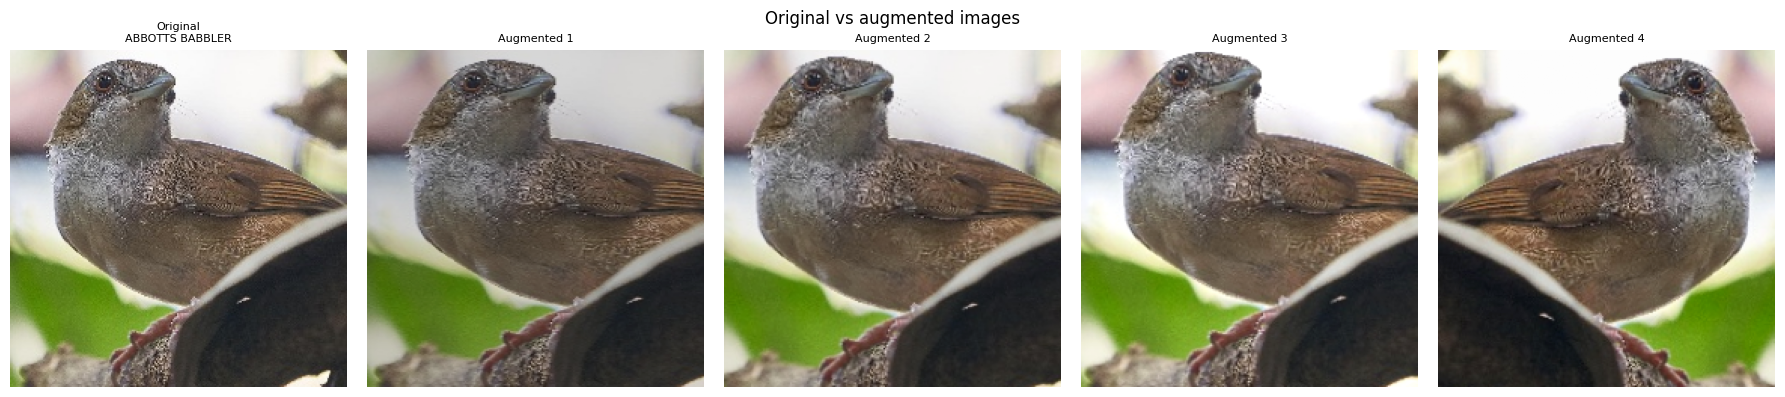

Tensor shape: torch.Size([3, 224, 224])
Value range: [-1.581, 2.082]


In [3]:
import matplotlib.pyplot as plt
import torch

label_names = dataset["train"].features["label"].names
sample = dataset["train"][0]
img = sample["image"]
label = label_names[sample["label"]]

# Apply train transform 4 times to show augmentation variety
fig, axes = plt.subplots(1, 5, figsize=(18, 4))

axes[0].imshow(img)
axes[0].set_title(f"Original\n{label}", fontsize=8)
axes[0].axis("off")

for i in range(1, 5):
    tensor = train_transforms(img)
    # Denormalize for display
    denorm = tensor * torch.tensor(IMAGENET_STD).view(3,1,1) + torch.tensor(IMAGENET_MEAN).view(3,1,1)
    axes[i].imshow(denorm.permute(1, 2, 0).clamp(0, 1))
    axes[i].set_title(f"Augmented {i}", fontsize=8)
    axes[i].axis("off")

plt.suptitle("Original vs augmented images", fontsize=12)
plt.tight_layout()
plt.show()

# Verify tensor shape and value range
tensor = train_transforms(img)
print(f"Tensor shape: {tensor.shape}")
print(f"Value range: [{tensor.min():.3f}, {tensor.max():.3f}]")

## 4. DataLoader

In [ ]:
from torch.utils.data import Dataset, DataLoader

# Wraps a HuggingFace split into a PyTorch-compatible Dataset.
# PyTorch's DataLoader requires a class with __len__ and __getitem__.
class BirdDataset(Dataset):
    def __init__(self, hf_split, transform):
        self.data = hf_split
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        sample = self.data[idx]
        image = self.transform(sample["image"])
        label = sample["label"]
        return image, label


# Wrap each split with the appropriate transform
train_dataset = BirdDataset(dataset["train"],      transform=train_transforms)
val_dataset   = BirdDataset(dataset["validation"], transform=eval_transforms)
test_dataset  = BirdDataset(dataset["test"],       transform=eval_transforms)

# DataLoader batches the data and shuffles the training set each epoch.
# num_workers=0 keeps it simple on Windows (multiprocessing can cause issues).
BATCH_SIZE = 32

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Train batches:      {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")
print(f"Test batches:       {len(test_loader)}")

# Verify a single batch has the right shape
images, labels = next(iter(train_loader))
print(f"\nBatch image shape: {images.shape}  (batch_size, channels, height, width)")
print(f"Batch label shape: {labels.shape}")